# Customer Retention

In [1]:
import importlib
import sys
from pathlib import Path
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Notebook output controls (clean vs verbose mode) ---
SHOW_VERBOSE_TABLES = False
PREVIEW_ROWS = 10

In [2]:

DATA_PATH = Path('../../data/processed/quality')

# 1. Use scan_csv (Lazy mode) - it doesn't load data yet, just maps it
orders = pl.scan_csv(DATA_PATH / 'orders_clean.csv')
prior = pl.scan_csv(DATA_PATH / 'order_products_prior_clean.csv')
products = pl.scan_csv(DATA_PATH / 'products_clean.csv')
aisles = pl.scan_csv(DATA_PATH / 'aisles_clean.csv')

# Load the dates file lazily too
order_dates_df = pl.scan_csv('../../data/processed/features/orders_with_dates.csv')

# 2. Chain the logic (Polars optimizes this whole "plan")
query = (
    orders
    .join(prior, on='order_id')
    .join(
        # Convert date inside the chain for speed
        order_dates_df.select([
            pl.col('order_id'), 
            pl.col('order_date').str.strptime(pl.Date, format="%Y-%m-%d")
        ]), 
        on='order_id', 
        how='left'
    )
    .join(
        products.select(['product_id', 'aisle_id', 'product_name']), 
        on='product_id', 
        how='left'
    )
    .join(
        aisles.select(['aisle_id', 'aisle']), 
        on='aisle_id', 
        how='left'
    )
    .drop('aisle_id')
)

# 3. Execution - This is where the magic happens
# Polars runs the entire multi-threaded join in one go
df = query.collect()

In [10]:
df["order_date"].min(), df["order_date"].max()

(Timestamp('2014-07-01 00:00:00'), Timestamp('2015-07-01 00:00:00'))

## 1. Order-Based Retention OR "Repeat Purchase Behavior"

เป้าหมาย: ดูว่า “วัดว่าลูกค้าสั่งซื้อซ้ำต่อเนื่องไปจนถึงครั้งที่เท่าไหร่”

สาเหตุ: เนื่องจาก ข้อมูลไม่มี เวลา ของผู้ไช้งาน เราจึงจําลลองวันจาก Reorder ด้วยมุมมอง การที่ลูกค้ากลับมาซื้อครั้งที่ 2, 3, 4... ก็คือการที่เขา "Retained" (ยังไม่เลิกใช้) นั่นเอง

In [3]:
# 1. Prepare Months
cohort_df = (
    df.with_columns([
        # No need to parse! It's already a date. 
        # Just truncate to the first of the month.
        pl.col("order_date").dt.truncate("1mo").alias("order_month")
    ])
    .unique(subset=["user_id", "order_month"]) 
)

# 2. Calculate Cohort Month (First purchase per user)
cohort_map = (
    cohort_df.group_by("user_id")
    .agg(pl.col("order_month").min().alias("cohort_month"))
)

# 3. Join and Calculate Cohort Index
cohort_df = (
    cohort_df.join(cohort_map, on="user_id")
    .with_columns(
        (
            (pl.col("order_month").dt.year() - pl.col("cohort_month").dt.year()) * 12 +
            (pl.col("order_month").dt.month() - pl.col("cohort_month").dt.month())
        ).alias("cohort_index")
    )
)

# 4. Build Cohort Table (Pivot)
# This creates the matrix of user counts per month/index
cohort_table = (
    cohort_df.pivot(
        values="user_id",
        index="cohort_month",
        on="cohort_index",
        aggregate_function="count"
    )
    .sort("cohort_month")
)


/tmp/ipykernel_197187/4140589807.py:31: DeprecationWarning: `aggregate_function='count'` input for `pivot` is deprecated. Please use `aggregate_function='len'`.
(Deprecated in version 0.20.5)
  cohort_df.pivot(


In [4]:
# --- Build RFM and compute Retention curve ---
# 1. Create RFM (user-level order frequency) from Polars df
rfm = (
    df.group_by("user_id")
    .agg(pl.col("order_id").n_unique().alias("total_orders"))
    .to_pandas()  # Convert to Pandas for segment code compatibility
)

# 2. Create Whale vs Regular segments from the existing user-level profile
whale_threshold = rfm["total_orders"].quantile(0.90)
segment_map = rfm[["user_id", "total_orders"]].copy()
segment_map["segment"] = "Regulars"
segment_map.loc[segment_map["total_orders"] >= whale_threshold, "segment"] = "Whales"

# 3. Convert cohort_df to pandas and merge segment info
cohort_df_pandas = cohort_df.to_pandas()
cohort_df_seg = cohort_df_pandas.merge(segment_map[["user_id", "segment"]], on="user_id", how="left")

# 4. Build segmented cohort table
cohort_table_seg = (
    cohort_df_seg
    .groupby(["segment", "cohort_month", "cohort_index"], observed=False)["user_id"]
    .nunique()
    .reset_index()
)

pivot_seg = cohort_table_seg.pivot_table(
    index=["segment", "cohort_month"],
    columns="cohort_index",
    values="user_id",
    fill_value=0
)

# FIX 1: make columns continuous
full_range = range(
    pivot_seg.columns.min(),
    pivot_seg.columns.max() + 1
)
pivot_seg = pivot_seg.reindex(columns=full_range)

# FIX 2: retention rate
retention_seg = pivot_seg.divide(
    pivot_seg.iloc[:, 0].replace(0, np.nan),
    axis=0
)

# FIX 3: sort
retention_seg = retention_seg.sort_index().sort_index(axis=1)

# --- Also compute overall retention (not segmented) for consistency ---
cohort_table_overall = (
    cohort_df_pandas
    .groupby(["cohort_month", "cohort_index"])["user_id"]
    .nunique()
    .reset_index()
)

pivot_overall = cohort_table_overall.pivot_table(
    index="cohort_month",
    columns="cohort_index",
    values="user_id",
    fill_value=0
)

# Make columns continuous
full_range = range(
    pivot_overall.columns.min(),
    pivot_overall.columns.max() + 1
)
pivot_overall = pivot_overall.reindex(columns=full_range)

# Compute retention
retention = pivot_overall.divide(
    pivot_overall.iloc[:, 0].replace(0, np.nan),
    axis=0
).sort_index().sort_index(axis=1)

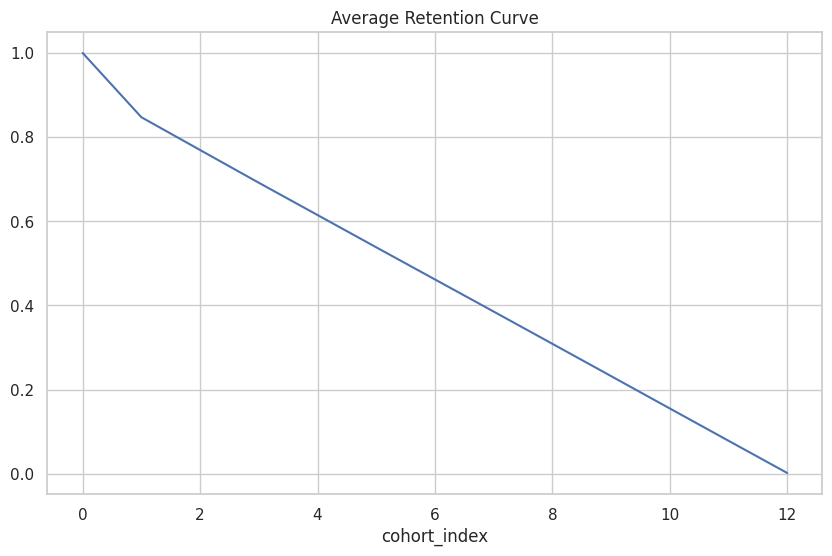

In [6]:
avg_retention = retention.mean()

# 2. Plot
plt.figure(figsize=(10, 6))
avg_retention.plot()
plt.title("Average Retention Curve")
plt.show()

หัวข้อ: Repeat Purchase Behavior Analysis (Order-Based Retention)

คำอธิบาย (Insight): * "จากการวิเคราะห์พฤติกรรมการสั่งซื้อซ้ำ พบว่าลูกค้าในทุก Cohort มีค่า Retention ในเชิงจำนวนครั้ง (Order Number) สูงมาก"

    "จุดที่ค่าตกลง (Diagonal Line) สะท้อนถึงขีดจำกัดของเวลาในชุดข้อมูล มากกว่าจะเป็นการ Churn จริงของลูกค้า"

ข้อจำกัด (Disclaimer): * "เนื่องจากวันที่สั่งซื้อ (Order Date) ถูกประมาณการย้อนหลัง ข้อมูลนี้จึงมุ่งเน้นไปที่การวิเคราะห์ความต่อเนื่องของพฤติกรรม (Behavioral Continuity) มากกว่าการวัดอัตราการรักษาสมาชิกตามเวลาจริง (Real-time Survival Rate)"

## retention by Whale vs Regular

In [8]:
# 1. Create Whale vs Regular segment classification in Polars
rfm_pl = (
    df.group_by("user_id")
    .agg(pl.col("order_id").n_unique().alias("total_orders"))
)

whale_threshold = rfm_pl.select(pl.col("total_orders").quantile(0.90)).item()

segment_map = rfm_pl.with_columns([
    pl.when(pl.col("total_orders") >= whale_threshold)
      .then(pl.lit("Whales"))
      .otherwise(pl.lit("Regulars"))
      .alias("segment")
]).select(["user_id", "segment"])

# 2. Join segments with cohort data
cohort_df_seg = cohort_df.join(segment_map, on="user_id", how="left")

# 3. Pivot by Segment and Cohort
pivot_seg = (
    cohort_df_seg
    .pivot(
        values="user_id",
        index=["segment", "cohort_month"],
        on="cohort_index",
        aggregate_function="len"  # Use 'len' instead of deprecated 'count'
    )
    .fill_null(0)
    .sort(["segment", "cohort_month"])
)

# 4. Calculate Retention: divide each column by the "0" column (first month)
index_cols = ["segment", "cohort_month"]
data_cols = [c for c in pivot_seg.columns if c not in index_cols]

retention_seg = pivot_seg.with_columns([
    (pl.col(col) / pl.col("0")).fill_null(0).alias(col)
    for col in data_cols
]).sort(["segment", "cohort_month"])

# 5. Convert to pandas for visualization (required for sns heatmap)
retention_seg_pandas = retention_seg.to_pandas().set_index(["segment", "cohort_month"])

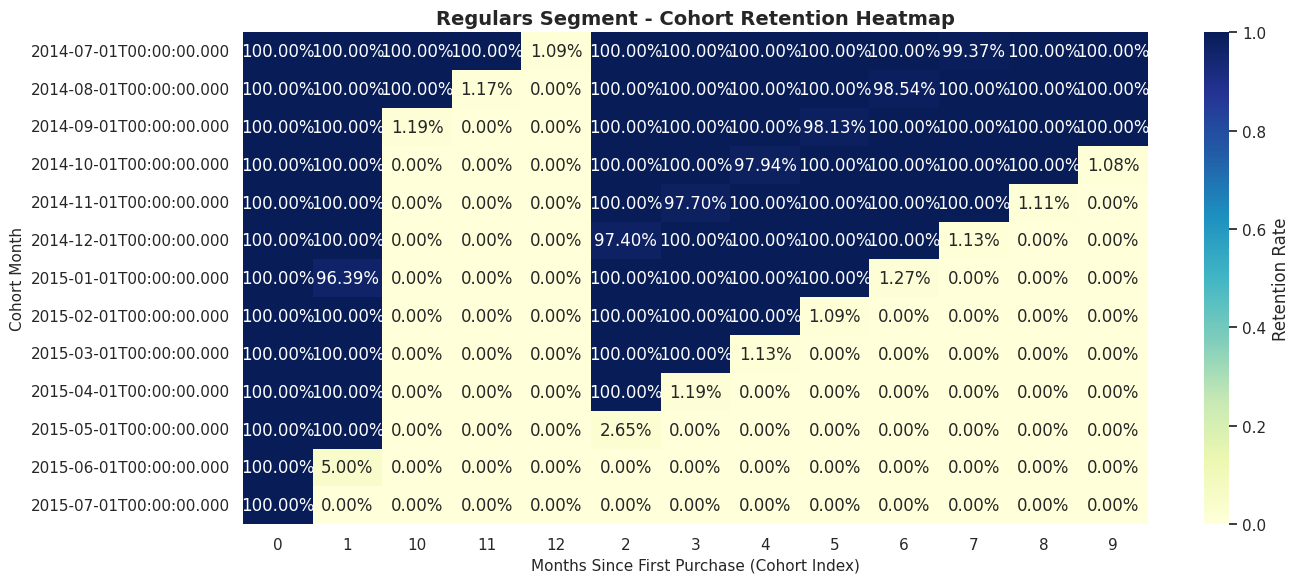

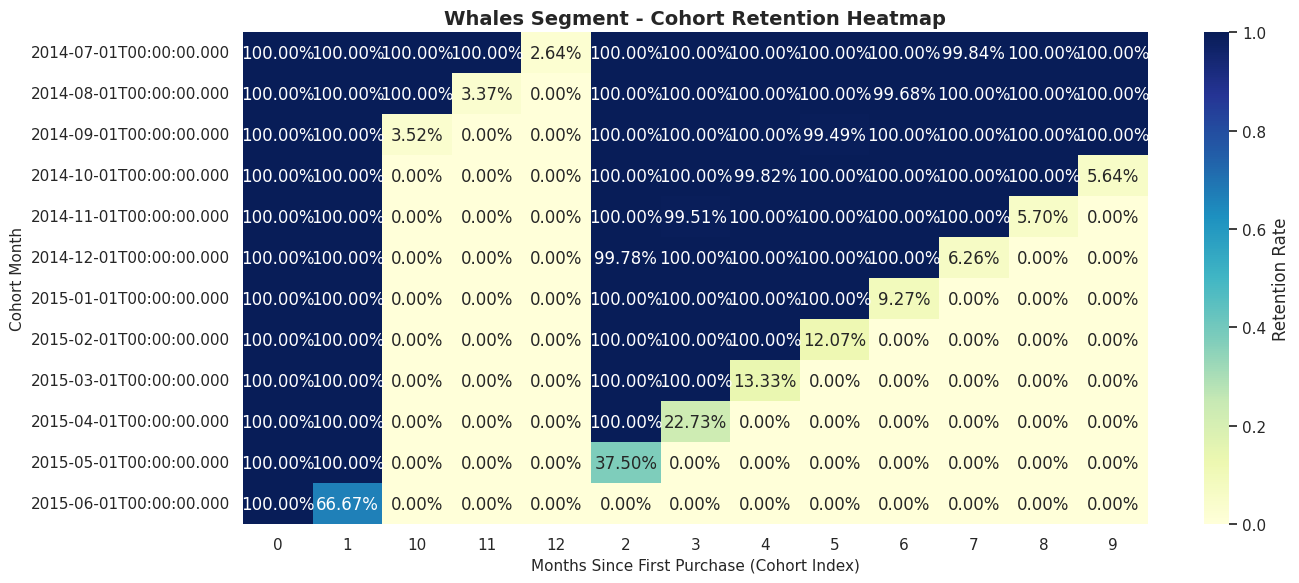

In [9]:
# Extract unique segments and plot heatmaps
segments = retention_seg_pandas.index.get_level_values(0).unique().tolist()
segments = sorted(segments, key=lambda x: (0 if x == "Regulars" else 1))

for seg in segments:
    seg_data = retention_seg_pandas.loc[seg].copy()
    
    # Sort and fill NaN values
    seg_data = seg_data.sort_index().sort_index(axis=1)
    seg_data = seg_data.fillna(0)
    
    # Create heatmap
    plt.figure(figsize=(14, 6))
    sns.heatmap(
        seg_data,
        annot=True,
        fmt=".2%",  # Display as percentage
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Retention Rate"},
    )
    
    plt.title(f"{seg} Segment - Cohort Retention Heatmap", fontsize=14, fontweight='bold')
    plt.xlabel("Months Since First Purchase (Cohort Index)", fontsize=11)
    plt.ylabel("Cohort Month", fontsize=11)
    plt.tight_layout()
    plt.show()

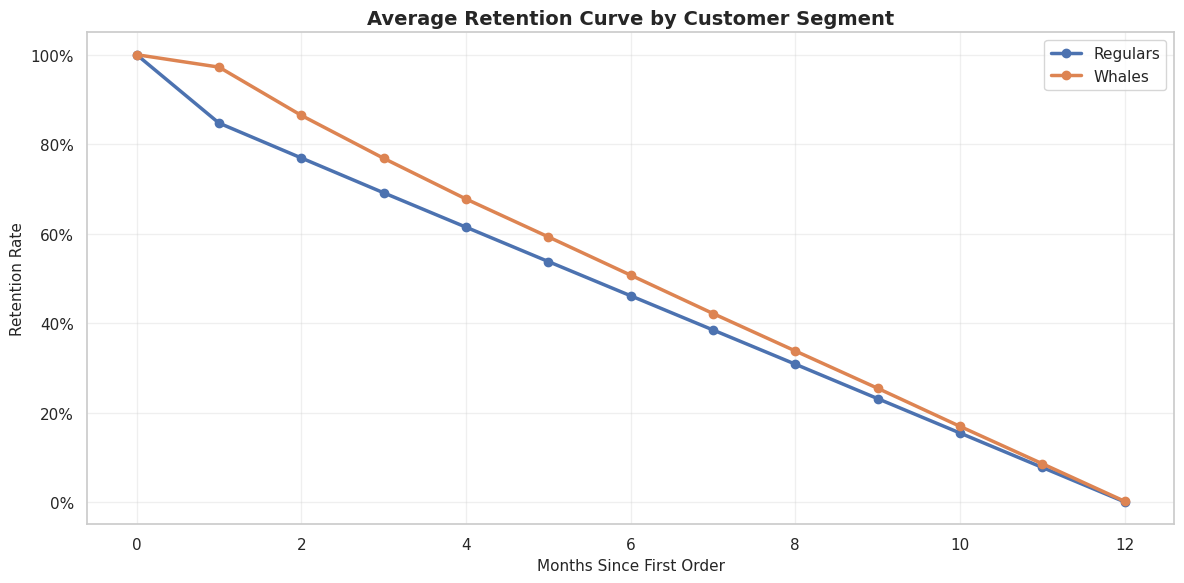

In [10]:
# Calculate and plot average retention curves by segment
plt.figure(figsize=(12, 6))

for seg in segments:
    seg_data = retention_seg_pandas.loc[seg]
    # Calculate mean retention per month index
    avg_retention = seg_data.mean(axis=0)
    
    # Extract numeric column names (month indices) and sort
    month_indices = sorted([int(col) for col in avg_retention.index])
    retention_values = [avg_retention[str(m)] for m in month_indices]
    
    plt.plot(month_indices, retention_values, marker='o', linewidth=2.5, 
             markersize=6, label=seg)

plt.legend(fontsize=11, loc='upper right')
plt.title("Average Retention Curve by Customer Segment", fontsize=14, fontweight='bold')
plt.xlabel("Months Since First Order", fontsize=11)
plt.ylabel("Retention Rate", fontsize=11)
plt.grid(alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.tight_layout()
plt.show()

In [ ]:
mean_retention = retention.mean()

print("Mean Retention Rates:")
print(mean_retention.to_string())


Mean Retention Rates:
cohort_index
0     1.000000
1     0.917890
2     0.909212
3     0.898986
4     0.888090
5     0.874344
6     0.857398
7     0.834914
8     0.802638
9     0.753700
10    0.671741
11    0.508336
12    0.020929


In [ ]:
median_retention = retention.median()

print("\nMedian Retention Rates:")
print(median_retention.to_string())


Median Retention Rates:
cohort_index
0     1.000000
1     1.000000
2     1.000000
3     1.000000
4     1.000000
5     1.000000
6     1.000000
7     1.000000
8     1.000000
9     1.000000
10    1.000000
11    0.508336
12    0.020929


## 2. Early Warning Signal

เป้าหมาย: “ทำนายว่าใครกำลังจะหาย”

In [15]:
# Calculate days since last order per user (using pure Polars)
snapshot_date = df.select(pl.col("order_date").max()).item()

user_churn = (
    df.group_by("user_id")
    .agg(pl.col("order_date").max().alias("last_order_date"))
    .with_columns([
        (pl.lit(snapshot_date) - pl.col("last_order_date")).dt.total_days().alias("days_since_last")
    ])
)

user_df = user_churn.to_pandas()  # Convert to pandas for easier manipulation

In [17]:
user_df["days_since_last"].describe()

count    206209.000000
mean         17.061782
std          10.672178
min           0.000000
25%           7.000000
50%          15.000000
75%          30.000000
max          30.000000
Name: days_since_last, dtype: float64

In [18]:
# Define churn threshold (users inactive for > 60 days)
threshold = user_df["days_since_last"].quantile(0.6)

user_df["churn_status"] = user_df["days_since_last"] > threshold

# Display churn statistics
print("\nChurn Analysis (Days Since Last Order):")
print(f"Threshold for churn: {threshold:.0f} days")
print(f"\nStats by churn status:")
print(user_df.groupby("churn_status")["days_since_last"].describe())


Churn Analysis (Days Since Last Order):
Threshold for churn: 21 days

Stats by churn status:
                 count       mean       std   min   25%   50%   75%   max
churn_status                                                             
False         124571.0   9.250419  5.588779   0.0   5.0   8.0  14.0  21.0
True           81638.0  28.981099  2.202295  22.0  30.0  30.0  30.0  30.0


## 3. Churn Prediction

เป้าหมาย: หา pattern ก่อน churn